# V39: LQ45 AI Strategy - TP/FP Optimization vs Markowitz Static Baseline

This notebook evaluates the **TP/FP Optimized AI Strategy** (using Moving Average targets) against a **Markowitz Static Portfolio** (Buy & Hold Optimized) and the IHSG Market Benchmark.

### Comparison Strategies:
1. **AI TP/FP Optimized (Proposed)**: AI-Gated Risk-Off (MA Target) + Graph Filter + Markowitz Optimization. High confidence threshold used.
2. **Markowitz Static (Baseline)**: Optimal Markowitz weights calculated at the start of the testing period and held throughout 2025.
3. **IHSG Proxy (Benchmark)**: Market mean return (Buy & Hold Index).

### Key Settings:
- **Target**: Prediction of 5-day MA slope direction.
- **Optimization**: Maximizing TP/FP Ratio on Training Data (2023-2024).
- **Transaction Fees**: 0.25% applied to every turnover (Active) or only at start (Static).

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
import xgboost as xgb
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')
plt.style.use('ggplot')

# --- 1. Load Data (LQ45) ---
file_path = 'data_lq45_2023_2025.xlsx'
if not os.path.exists(file_path):
    file_path = 'dataset_2023_2025.xlsx'

data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_price = (1 + market_return).cumprod() * 100

print(f"✓ Data Loaded: {len(data)} rows")

✓ Data Loaded: 712 rows


In [2]:
# --- 2. MA Labeling & Feature Engineering ---

features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
ma5 = market_price.rolling(window=5).mean()
ma20 = market_price.rolling(window=20).mean()
ma50 = market_price.rolling(window=50).mean()
features['Dist_MA20'] = market_price / ma20
features['Dist_MA50'] = market_price / ma50

# TARGET: MA Slope Direction
target = (ma5.shift(-1) > ma5).astype(int)

features = features.dropna()
target = target.reindex(features.index).fillna(0)

train_mask = (features.index.year <= 2024)
test_mask = (features.index.year == 2025)

X_train, y_train = features.loc[train_mask], target.loc[train_mask]
X_test = features.loc[test_mask]

xgb_model = xgb.XGBClassifier(n_estimators=120, learning_rate=0.04, max_depth=6, random_state=42, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# TP/FP Optimization Curve
train_probs = xgb_model.predict_proba(X_train)[:, 1]
thresholds = np.arange(0.40, 0.76, 0.01)
tp_fp_ratios = []
for t in thresholds:
    preds = (train_probs >= t).astype(int)
    if np.sum(preds) == 0: tp_fp_ratios.append(0); continue
    tn, fp, fn, tp = confusion_matrix(y_train, preds).ravel()
    tp_fp_ratios.append(tp / fp if fp > 0 else tp)

opt_t = thresholds[np.argmax(tp_fp_ratios)]
print(f"Optimized Threshold Identified: {opt_t:.2f} (In-Sample Ratio: {max(tp_fp_ratios):.2f})")

Optimized Threshold Identified: 0.71 (In-Sample Ratio: 182.00)


In [3]:
# --- 3. Run Simulation Logic ---

def get_mis_assets(returns_window, correlation_threshold=0.4):
    corr_mat = returns_window.corr()
    G = nx.Graph()
    G.add_nodes_from(returns_window.columns)
    for i in range(len(returns_window.columns)):
        for j in range(i+1, len(returns_window.columns)):
            if abs(corr_mat.iloc[i, j]) > correlation_threshold: G.add_edge(returns_window.columns[i], returns_window.columns[j])
    return list(nx.approximation.maximum_independent_set(G))

def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu, sigma = selected_returns.mean() * 252, selected_returns.cov() * 252
    res = minimize(lambda w: -(np.sum(w*mu)/(np.sqrt(np.dot(w.T, np.dot(sigma, w))) + 1e-6)), 
                   [1./len(mu)]*len(mu), method='SLSQP', 
                   bounds=tuple((0, 1) for _ in range(len(mu))), 
                   constraints=({'type': 'eq', 'fun': lambda x: np.sum(x) - 1}))
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def run_simulation(strategy_type, test_dates, returns, ai_probs=None, threshold=0.5, fee=0.0025):
    val, history, dates = 100.0, [100.0], [test_dates[0]]
    prev_weights = {}
    static_weights = None
    
    for i, date in enumerate(test_dates[:-1]):
        loc_idx = returns.index.get_loc(date)
        window_rets = returns.iloc[loc_idx-30:loc_idx]
        
        if strategy_type == 'Proposed AI':
            is_risk_off = ai_probs.loc[date] < threshold
            if is_risk_off: weights = {'CASH': 1.0}
            else:
                selected = get_mis_assets(window_rets)
                weights = optimize_markowitz(window_rets[selected])
        elif strategy_type == 'Markowitz Static':
            if static_weights is None:
                static_weights = optimize_markowitz(window_rets)
            weights = static_weights
        
        # Transaction Costs
        all_assets = set(list(weights.keys()) + list(prev_weights.keys()))
        turnover = sum(abs(weights.get(a, 0) - prev_weights.get(a, 0)) for a in all_assets)
        val -= (val * turnover * fee)
        
        next_date = test_dates[i+1]
        day_ret = 0 if 'CASH' in weights else sum(w * returns.loc[next_date, a] for a, w in weights.items())
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date); prev_weights = weights
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

Running AI Strategy...
Running Markowitz Static...
Calculating IHSG Benchmark...


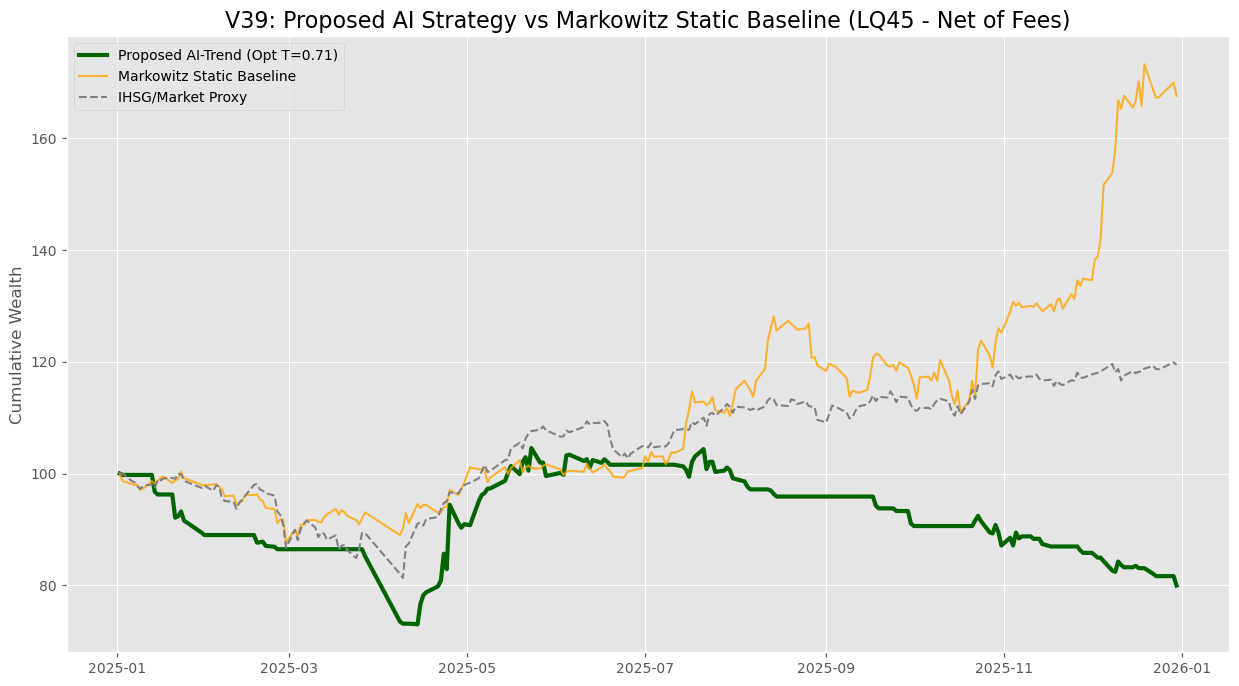

,Strategy,Total Return %,Sharpe,MaxDD
0,AI Proposed,-20.04%,-0.73,-26.97%
1,Markowitz Static,67.60%,2.19,-13.38%
2,IHSG Proxy,19.44%,1.04,-18.70%


In [4]:
# --- 4. Backtest Execution & Comparison ---
test_dates = X_test.index
test_probs = pd.Series(xgb_model.predict_proba(X_test)[:, 1], index=test_dates)
fee = 0.0025

print("Running AI Strategy...")
res_ai = run_simulation('Proposed AI', test_dates, returns, test_probs, threshold=opt_t, fee=fee)
print("Running Markowitz Static...")
res_static = run_simulation('Markowitz Static', test_dates, returns, fee=fee)
print("Calculating IHSG Benchmark...")
benchmark = pd.DataFrame({'Portfolio_Value': (market_price.loc[test_dates] / market_price.loc[test_dates[0]] * 100)}, index=test_dates)

# Visualization
plt.figure(figsize=(15, 8))
plt.plot(res_ai.index, res_ai['Portfolio_Value'], label=f"Proposed AI-Trend (Opt T={opt_t:.2f})", color='darkgreen', linewidth=3)
plt.plot(res_static.index, res_static['Portfolio_Value'], label="Markowitz Static Baseline", color='orange', alpha=0.8)
plt.plot(benchmark.index, benchmark['Portfolio_Value'], label="IHSG/Market Proxy", linestyle='--', color='gray')

plt.title("V39: Proposed AI Strategy vs Markowitz Static Baseline (LQ45 - Net of Fees)", fontsize=16)
plt.ylabel("Cumulative Wealth")
plt.legend()
plt.grid(True)
plt.show()

# Summary Table
summary = []
for label, df in [("AI Proposed", res_ai), ("Markowitz Static", res_static), ("IHSG Proxy", benchmark)]:
    rets = df['Portfolio_Value'].pct_change().dropna()
    r = (df['Portfolio_Value'].iloc[-1] / 100) - 1
    sh = (rets.mean() * 252) / (rets.std() * np.sqrt(252))
    mdd = (df['Portfolio_Value'] / df['Portfolio_Value'].cummax() - 1).min()
    summary.append({'Strategy': label, 'Total Return %': f"{r:.2%}", 'Sharpe': round(sh, 2), 'MaxDD': f"{mdd:.2%}"})

display(pd.DataFrame(summary))